> dataset structure

In [1]:
import pandas as pd

df = pd.read_csv("dailyActivity_merged.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist(),"\n")
print(df.head().to_string(index=False))

Shape: (457, 15)

Columns: ['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'] 

        Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  SedentaryMinutes  Calories
1503960366    3/25/2016       11004           7.11             7.11                       0.0                2.57                      0.46                 4.07                      0.0                 33                   12                   205               804      1819
1503960366    3/26/2016       17609          11.55            11.55                       0.0                6.92     

> dataset inspection

In [2]:
print(df.dtypes)

Id                            int64
ActivityDate                    str
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object


In [3]:
print(df.isnull().sum())

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64


In [4]:
df.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,4.570000e+02,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,4.628595e+09,6546.562363,4.663523,4.609847,0.179427,1.180897,0.478643,2.890197,0.001904,16.623632,13.070022,170.070022,995.282276,2189.452954
std,2.293781e+09,5398.493064,4.082072,4.068540,0.849232,2.487159,0.830995,2.237523,0.008487,28.919704,36.208635,122.205372,337.021404,815.484523
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,0.000000
25%,2.347168e+09,1988.000000,1.410000,1.280000,0.000000,0.000000,0.000000,0.870000,0.000000,0.000000,0.000000,64.000000,728.000000,1776.000000
50%,4.057193e+09,5986.000000,4.090000,4.090000,0.000000,0.000000,0.020000,2.930000,0.000000,0.000000,1.000000,181.000000,1057.000000,2062.000000
75%,6.391747e+09,10198.000000,7.160000,7.110000,0.000000,1.310000,0.670000,4.460000,0.000000,25.000000,16.000000,257.000000,1285.000000,2667.000000
max,8.877689e+09,28497.000000,27.530001,27.530001,6.727057,21.920000,6.400000,12.510000,0.100000,202.000000,660.000000,720.000000,1440.000000,4562.000000


> No missing values and all predictors are numeric except 'ActivityDate'

In [5]:
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])
print(df.dtypes[["ActivityDate"]])

ActivityDate    datetime64[us]
dtype: object


In [6]:
# feature analysis
df_model = df.drop(columns=["Id"])
print("Model dataframe shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())

Model dataframe shape: (457, 14)
Columns: ['ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']


> Extract structured temporal signals from ActivityDate for modeling.

In [7]:
df_model["day"] = df_model["ActivityDate"].dt.day
df_model["weekday"] = df_model["ActivityDate"].dt.weekday
df_model["month"] = df_model["ActivityDate"].dt.month

In [8]:
df_model = df_model.drop(columns=["ActivityDate"])

print("Shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())
print("\n",df_model.head().to_string(index=False))

Shape: (457, 16)
Columns: ['TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'day', 'weekday', 'month']

  TotalSteps  TotalDistance  TrackerDistance  LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  SedentaryMinutes  Calories  day  weekday  month
      11004           7.11             7.11                       0.0                2.57                      0.46                 4.07                      0.0                 33                   12                   205               804      1819   25        4      3
      17609          11.55            11.55                       0.0                6.92                      0.73     

> Redundancy Detection (Correlation Scan)

In [9]:
corr_matrix = df_model.drop(columns=["Calories"]).corr()
print(corr_matrix.round(3).to_string(index=False))

 TotalSteps  TotalDistance  TrackerDistance  LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  SedentaryMinutes    day  weekday  month
      1.000          0.987            0.983                     0.146               0.734                     0.542                0.776                    0.082              0.700                0.238                 0.654            -0.285 -0.122    0.013  0.126
      0.987          1.000            0.995                     0.164               0.792                     0.515                0.745                    0.081              0.714                0.231                 0.614            -0.260 -0.126    0.013  0.128
      0.983          0.995            1.000                     0.095               0.789                     0.516                0.738                    0.077              0.712                0.232    

In [10]:
high_corr_pairs = []

cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.95:
            high_corr_pairs.append((cols[i], cols[j], round(val,3)))

high_corr_pairs

[('TotalSteps', 'TotalDistance', np.float64(0.987)),
 ('TotalSteps', 'TrackerDistance', np.float64(0.983)),
 ('TotalDistance', 'TrackerDistance', np.float64(0.995))]

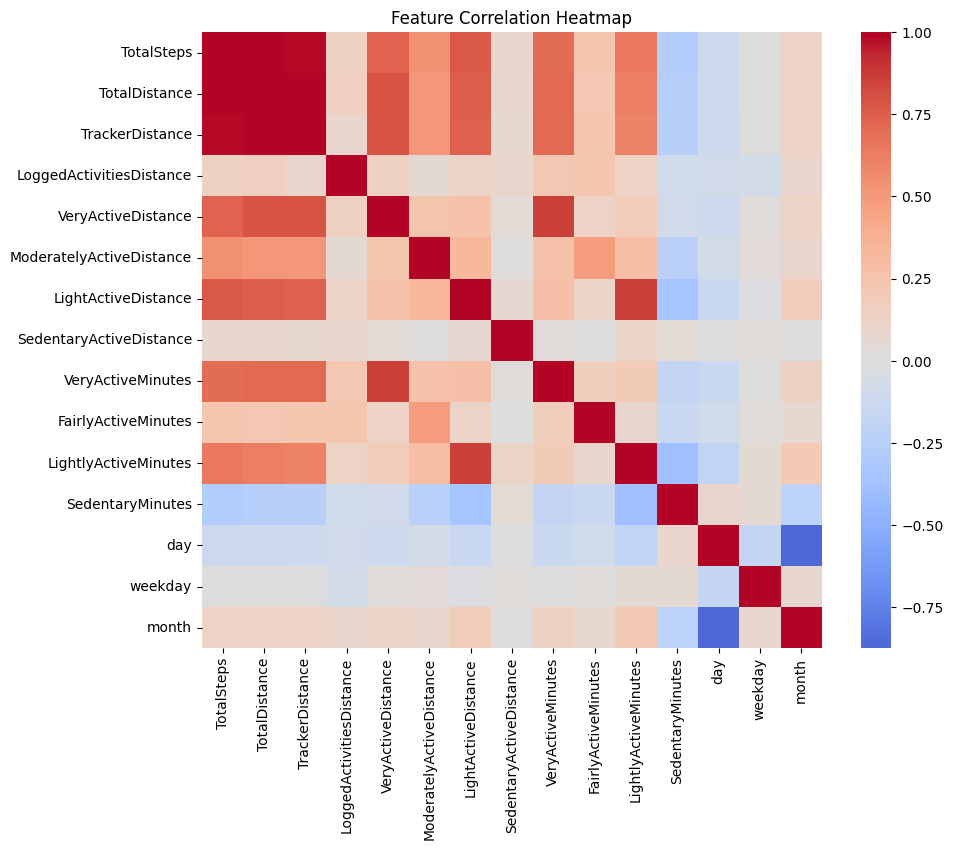

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

> Insight: TotalSteps, TotalDistance, and TrackerDistance represent the same movement signal; keeping all three introduces redundancy.

> Keep: TotalSteps (most interpretable primary activity metric)

> Drop candidates: TotalDistance TrackerDistance

In [12]:
df_model = df_model.drop(columns=["TotalDistance", "TrackerDistance"])
print("Shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())

Shape: (457, 14)
Columns: ['TotalSteps', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'day', 'weekday', 'month']


> Train / Validation / Test Split

> Scaling approved and Calories will be excluded from clustering.
> Insight: Proper scaling ensures distance-based algorithms behave correctly and prevents target leakage in clustering.

In [13]:
X = df_model.drop(columns=["Calories"])
y = df_model["Calories"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (457, 13)
y shape: (457,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (274, 13)
Validation: (91, 13)
Test: (92, 13)


> Feature Scaling (Supervised Pipeline)

In [15]:
from sklearn.preprocessing import StandardScaler

scalaler = StandardScaler()

X_train_scaled = scalaler.fit_transform(X_train)
X_val_scaled = scalaler.transform(X_val)
X_test_scaled = scalaler.transform(X_test)

print("Train : ", X_train_scaled.shape)
print("Validation : ", X_val_scaled.shape)
print("Test : ", X_test_scaled.shape)

Train :  (274, 13)
Validation :  (91, 13)
Test :  (92, 13)


> **Linear Regression**

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_val_pred = model.predict(X_val_scaled)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 592.4733380736457
MAE: 464.0194258556592
R2: 0.49630740683840735


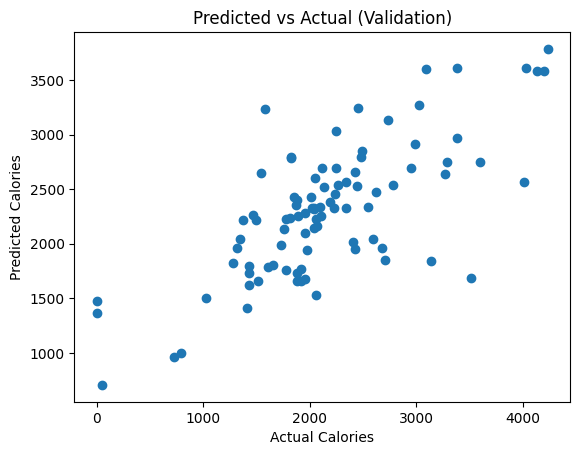

In [17]:
plt.scatter(y_val, y_val_pred)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Predicted vs Actual (Validation)")
plt.show()

> ~50% of calorie variance, indicating moderate predictive power with remaining nonlinear structure.

> Random Forest Regressor

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)

y_val_pred_rf = rf.predict(X_val_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
r2_rf = r2_score(y_val, y_val_pred_rf)

print("RMSE (RF):", rmse_rf)
print("MAE (RF):", mae_rf)
print("R2 (RF):", r2_rf)

RMSE (RF): 544.2162672819157
MAE (RF): 401.9950141921571
R2 (RF): 0.5750175653387459


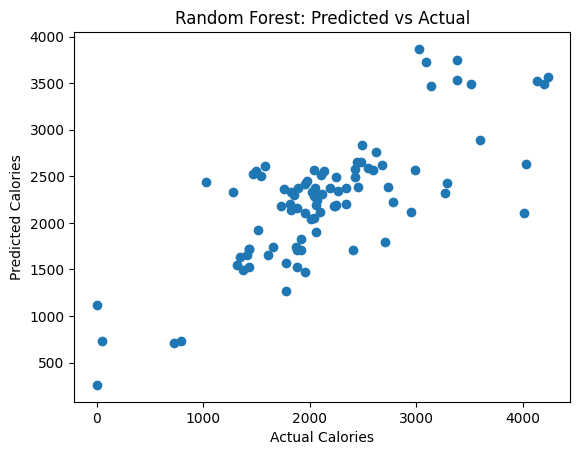

In [19]:
plt.scatter(y_val, y_val_pred_rf)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

> Random Forest improves performance over Linear Regression (R² ↑ from ~0.50 → ~0.58), indicating nonlinear relationships in the data.

In [20]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

TotalSteps                  0.360295
SedentaryMinutes            0.157024
VeryActiveMinutes           0.125093
LightActiveDistance         0.072034
LightlyActiveMinutes        0.066462
FairlyActiveMinutes         0.059491
day                         0.057058
weekday                     0.021369
ModeratelyActiveDistance    0.020417
LoggedActivitiesDistance    0.020236
month                       0.019885
VeryActiveDistance          0.016630
SedentaryActiveDistance     0.004007
dtype: float64


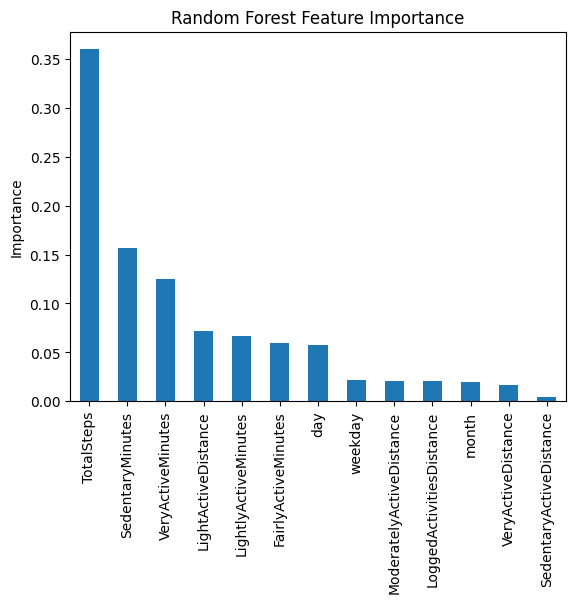

In [21]:
feature_importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

> Dropped month, VeryActiveDistance, SedentaryActiveDistance.

In [22]:
df_model = df_model.drop(columns=["month", "VeryActiveDistance", "SedentaryActiveDistance"])
print("df_model shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())

df_model shape: (457, 11)
Columns: ['TotalSteps', 'LoggedActivitiesDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'day', 'weekday']


In [23]:
X = df_model.drop(columns=["Calories"])
y = df_model["Calories"]
print("X shape:", X.shape)

X shape: (457, 10)


In [24]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (274, 10)
Validation: (91, 10)
Test: (92, 10)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train:", X_train_scaled.shape)

Scaled train: (274, 10)


> Ridge Regression (Apply L2-regularized linear regression to reduce variance and stabilize coefficients.)

In [26]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_val_pred_ridge = ridge.predict(X_val_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
r2_ridge = r2_score(y_val, y_val_pred_ridge)

print("RMSE_Ridge:", rmse_ridge)
print("MAE_Ridge:", mae_ridge)
print("R2_Ridge:", r2_ridge)

RMSE_Ridge: 624.3018546538088
MAE_Ridge: 473.93490618349034
R2_Ridge: 0.44073557834720634


In [27]:
ridge_importance = pd.Series(
    abs(ridge.coef_),
    index=X_train.columns
).sort_values(ascending=False)

print(ridge_importance)

VeryActiveMinutes           371.786625
LightActiveDistance         338.080226
FairlyActiveMinutes         255.048661
SedentaryMinutes            217.323277
LightlyActiveMinutes        116.566903
TotalSteps                  100.884538
day                          53.208364
LoggedActivitiesDistance     38.206173
weekday                      36.571254
ModeratelyActiveDistance      9.636493
dtype: float64


> ridge performs worse than Linear Regression and Random Forest, suggesting strong nonlinear relationships dominate the dataset.

> **Lasso Regression**

In [28]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_val_pred_lasso = lasso.predict(X_val_scaled)

rmse_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
r2_lasso = r2_score(y_val, y_val_pred_lasso)

print("RMSE_Lasso:", rmse_lasso)
print("MAE_Lasso:", mae_lasso)
print("R2_Lasso:", r2_lasso)

RMSE_Lasso: 624.4975630427215
MAE_Lasso: 473.9311948466877
R2_Lasso: 0.4403848829458048


In [29]:
lasso_importance = pd.Series(
    abs(lasso.coef_),
    index=X_train.columns
).sort_values(ascending=False)

print(lasso_importance)

VeryActiveMinutes           369.977800
LightActiveDistance         338.582985
FairlyActiveMinutes         254.078597
SedentaryMinutes            216.841889
LightlyActiveMinutes        113.258630
TotalSteps                   97.794462
day                          52.001795
LoggedActivitiesDistance     36.953547
weekday                      35.681624
ModeratelyActiveDistance      9.127952
dtype: float64


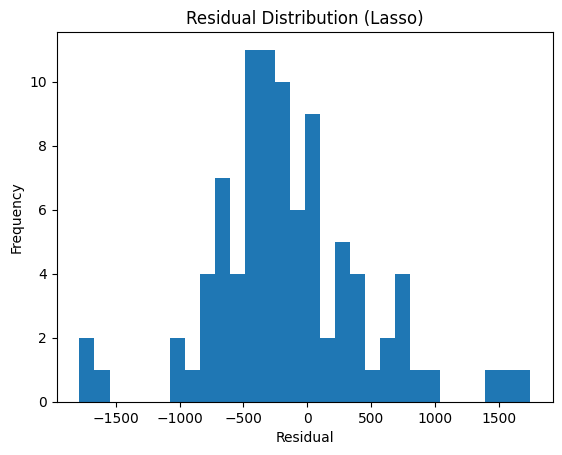

In [30]:
residuals = y_val - y_val_pred_lasso

plt.hist(residuals, bins=30)
plt.title("Residual Distribution (Lasso)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

> Lasso performs almost identically to Ridge and Residuals roughly centered around zero but with wide spread, indicating model underfitting.

> **Gradient Boosting Regressor**

In [31]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_scaled, y_train)

y_val_pred_gbr = gbr.predict(X_val_scaled)

rmse_gbr = np.sqrt(mean_squared_error(y_val, y_val_pred_gbr))
mae_gbr = mean_absolute_error(y_val, y_val_pred_gbr)
r2_gbr = r2_score(y_val, y_val_pred_gbr)

print("RMSE_GBR:", rmse_gbr)
print("MAE_GBR:", mae_gbr)
print("R2_GBR:", r2_gbr)

RMSE_GBR: 553.9274340995679
MAE_GBR: 418.56388876502325
R2_GBR: 0.5597152012416181


> Gradient Boosting improves over linear models but is slightly weaker than Random Forest, making Random Forest the best supervised model for this dataset.

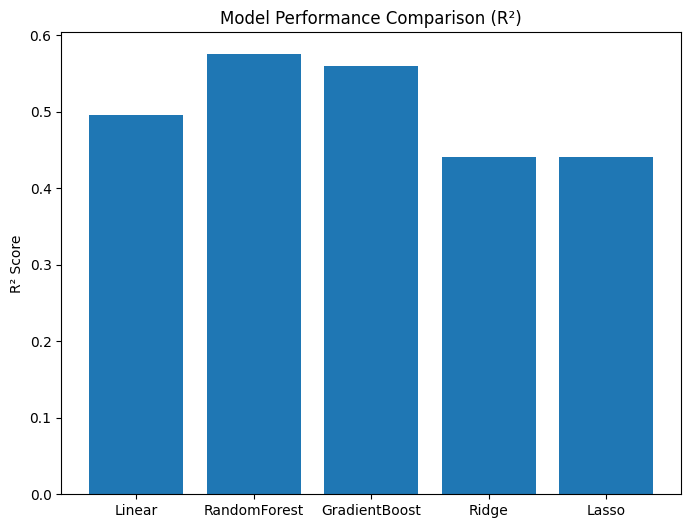

In [32]:
# Model Performance Comparison

models = ["Linear", "RandomForest", "GradientBoost", "Ridge", "Lasso"]
r2_scores = [0.4963, 0.5750, 0.5597, 0.4407, 0.4404]

plt.figure(figsize=(8, 6))
plt.bar(models, r2_scores)
plt.title("Model Performance Comparison (R²)")
plt.ylabel("R² Score")
plt.show()

> **KNN Regressor**

In [33]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_val_pred_knn = knn.predict(X_val_scaled)

rmse_knn = np.sqrt(mean_squared_error(y_val, y_val_pred_knn))
mae_knn = mean_absolute_error(y_val, y_val_pred_knn)
r2_knn = r2_score(y_val, y_val_pred_knn)

print("RMSE_KNN:", rmse_knn)
print("MAE_KNN:", mae_knn)
print("R2_KNN:", r2_knn)

RMSE_KNN: 655.7670177269223
MAE_KNN: 497.2571428571428
R2_KNN: 0.382940445605331


> Current supervised model ranking (by R²):

- Random Forest → 0.575 (best)

- Gradient Boosting → 0.560

- Linear Regression → 0.496

- Ridge → 0.441

- Lasso → 0.440

- KNN → 0.383

> **KMeans**

In [34]:
X_cluster = df_model.drop(columns=["Calories"])
print("Cluster feature shape:", X_cluster.shape)

Cluster feature shape: (457, 10)


In [35]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Scaled cluster shape:", X_cluster_scaled.shape)

Scaled cluster shape: (457, 10)


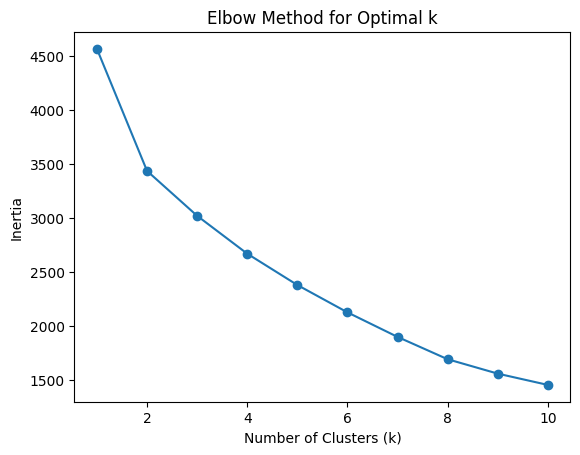

In [36]:
from sklearn.cluster import KMeans

inertia = []

k_values = range(1,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

> Run KMeans (k = 3)

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

print("Cluster counts:\n", pd.Series(cluster_labels).value_counts().sort_index())

Cluster counts:
 0    101
1    177
2    179
Name: count, dtype: int64


In [38]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_cluster_scaled, cluster_labels)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.20163975040677035


In [39]:
df_cluster = df_model.copy()
df_cluster["Cluster"] = cluster_labels

print(df_cluster.head().to_string(index=False))

 TotalSteps  LoggedActivitiesDistance  ModeratelyActiveDistance  LightActiveDistance  VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  SedentaryMinutes  Calories  day  weekday  Cluster
      11004                       0.0                      0.46                 4.07                 33                   12                   205               804      1819   25        4        2
      17609                       0.0                      0.73                 3.91                 89                   17                   274               588      2154   26        5        0
      12736                       0.0                      0.16                 3.71                 56                    5                   268               605      1944   27        6        2
      13231                       0.0                      0.79                 4.95                 39                   20                   224              1080      1932   28        0        2
      1204

In [40]:
cluster_profile = df_cluster.groupby("Cluster").mean()

print(cluster_profile.to_string())

           TotalSteps  LoggedActivitiesDistance  ModeratelyActiveDistance  LightActiveDistance  VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  SedentaryMinutes     Calories        day   weekday
Cluster                                                                                                                                                                                                         
0        13410.158416                  0.743432                  1.469802             4.363366          54.465347            40.841584            230.306931        845.970297  2863.435644   6.841584  2.970297
1         1593.790960                  0.011772                  0.054011             0.701695           1.988701             1.519774             49.209040       1169.288136  1730.039548  11.282486  3.084746
2         7571.240223                  0.026972                  0.339274             4.223017           9.743017             8.821229            255.592179        

> 3D Cluster Visualization (Plotly)

In [41]:
viz_df = df_cluster[[
    "TotalSteps",
    "VeryActiveMinutes",
    "SedentaryMinutes",
    "Cluster"
]].copy()

In [42]:
import plotly.express as px

fig = px.scatter_3d(
    viz_df,
    x="TotalSteps",
    y="VeryActiveMinutes",
    z="SedentaryMinutes",
    color=viz_df["Cluster"].astype(str),
    title="3D Activity Clusters"
)

fig.show()

> PCA Visualization

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

PCA shape: (457, 2)
Explained variance ratio: [0.34353626 0.13016449]


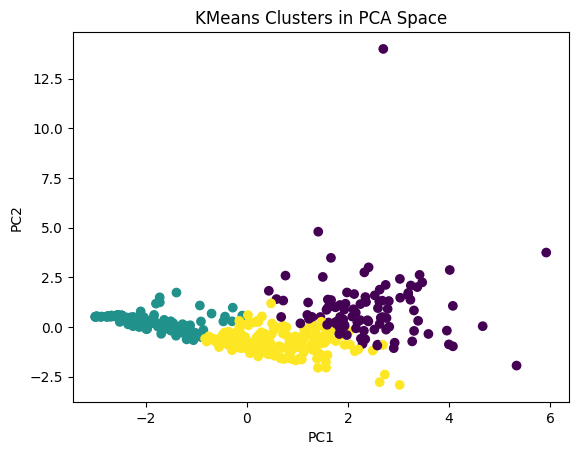

In [44]:
import matplotlib.pyplot as plt

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters in PCA Space")
plt.show()

> Hierarchical Clustering

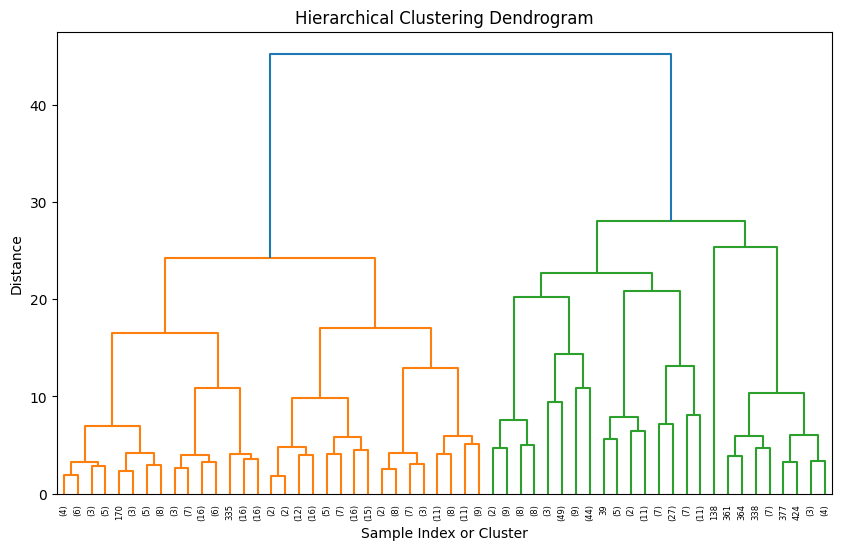

In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X_cluster_scaled, method="ward")

plt.figure(figsize=(10,6))

dendrogram(
    Z,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index or Cluster")
plt.ylabel("Distance")

plt.show()

In [46]:
from scipy.cluster.hierarchy import fcluster

hier_labels = fcluster(Z, 3, criterion="maxclust")

print("Hierarchical cluster counts:\n", pd.Series(hier_labels).value_counts().sort_index())

comparison = pd.crosstab(cluster_labels, hier_labels)

print("\n",comparison)

Hierarchical cluster counts:
 1    234
2    203
3     20
Name: count, dtype: int64

 col_0    1    2   3
row_0              
0        0   81  20
1      171    6   0
2       63  116   0


> Hierarchical clustering detected a small extreme activity subgroup (20 records) within the highly active users.
> Hierarchical clustering is more sensitive to outliers, which is why it separated this small group.

> **DBSCAN Clustering**

In [47]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

db_labels = dbscan.fit_predict(X_cluster_scaled)

print("DBSCAN cluster counts:\n", pd.Series(db_labels).value_counts().sort_index())

df_dbscan = df_model.copy()
df_dbscan["DBSCAN_cluster"] = db_labels

print(df_dbscan.head().to_string(index=False))

DBSCAN cluster counts:
 -1     68
 0    378
 1      6
 2      5
Name: count, dtype: int64
 TotalSteps  LoggedActivitiesDistance  ModeratelyActiveDistance  LightActiveDistance  VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  SedentaryMinutes  Calories  day  weekday  DBSCAN_cluster
      11004                       0.0                      0.46                 4.07                 33                   12                   205               804      1819   25        4               0
      17609                       0.0                      0.73                 3.91                 89                   17                   274               588      2154   26        5              -1
      12736                       0.0                      0.16                 3.71                 56                    5                   268               605      1944   27        6              -1
      13231                       0.0                      0.79                 4.95      

| Algorithm    | Result                                 |
| ------------ | -------------------------------------- |
| KMeans       | 3 behavioral clusters                  |
| Hierarchical | 3 clusters + small extreme subgroup    |
| DBSCAN       | 1 main group + sparse outlier patterns |

> Most users follow similar activity behavior,
while a small fraction exhibit extreme or irregular activity patterns.

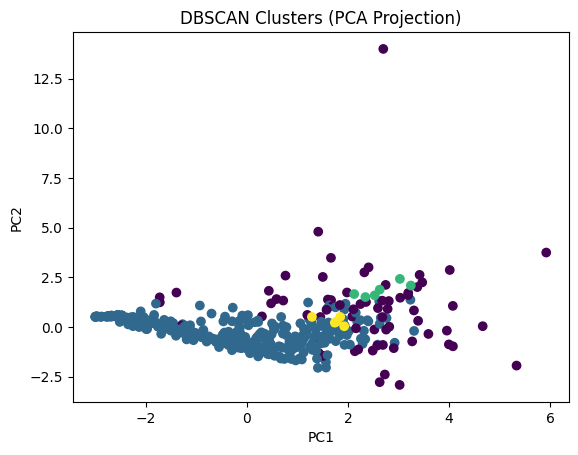

In [48]:
dbscan_viz = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": db_labels
})

plt.scatter(
    dbscan_viz["PC1"],
    dbscan_viz["PC2"],
    c=dbscan_viz["Cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (PCA Projection)")

plt.show()

> DBSCAN eps Tuning (k-distance method)

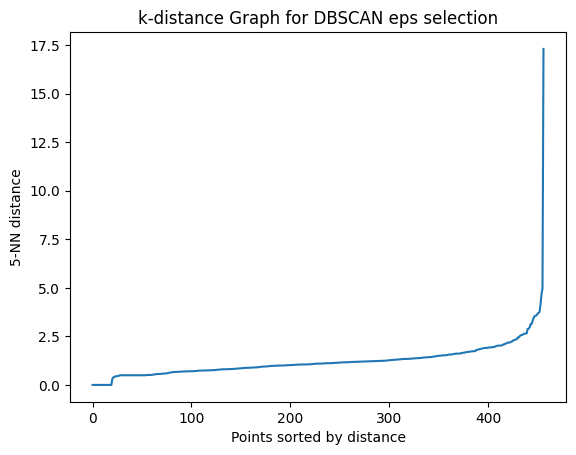

In [49]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_cluster_scaled)

distances, indices = neighbors_fit.kneighbors(X_cluster_scaled)

distances = np.sort(distances[:,4])   # distance to 5th nearest neighbor

plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN distance")
plt.title("k-distance Graph for DBSCAN eps selection")
plt.show()

In [50]:
dbscan_tuned = DBSCAN(eps=2.6, min_samples=11)
db_labels_tuned = dbscan_tuned.fit_predict(X_cluster_scaled)

print("DBSCAN tuned cluster counts:\n", pd.Series(db_labels_tuned).value_counts().sort_index())

DBSCAN tuned cluster counts:
 -1     27
 0    430
Name: count, dtype: int64


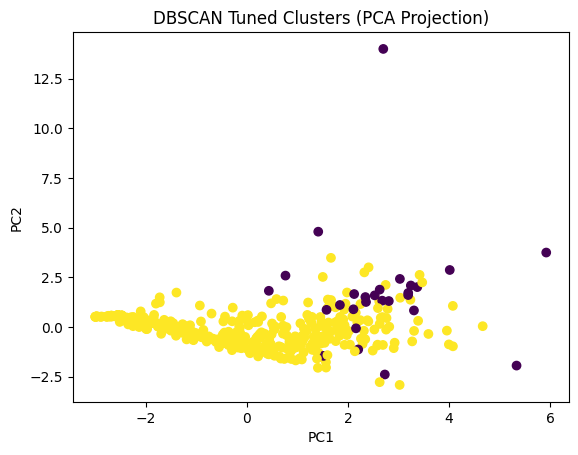

In [51]:
dbscan_tuned_viz = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": db_labels_tuned
})

plt.scatter(
    dbscan_tuned_viz["PC1"],
    dbscan_tuned_viz["PC2"],
    c=dbscan_tuned_viz["Cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Tuned Clusters (PCA Projection)")

plt.show()

> Main conclusions:

1. Calories depend primarily on movement volume and intensity.

2. Users follow a behavioral activity spectrum.

3. Random Forest provides the most accurate predictions.

4. Density-based clustering reveals true outlier behaviors.